In [1]:
import numpy as np

from matplotlib import pyplot as plt

# Define Fiducial Cosmology and Basic Functions

In [2]:
speed_of_light = 3e5 # speed of light in km/s

# Planck Cosmology

Om_fid = 0.3153
H0_fid = 67.36

rd_fid =  147.09 # in Mpc

In [3]:
from scipy.interpolate import interp1d

Delta_z = 0.5
znodes = np.arange(0, np.ceil(2.33/Delta_z) * Delta_z + 1e-5, Delta_z); znodes = np.concatenate((znodes, [1100,]))
print(znodes)
Nparams = len(znodes)

def DH_per_rd(zz, params, znodes = znodes):
    
    # Here params = [(D_H/rd) / (D_H / rd) - 1] (z = znode)
    
    relative_factor = interp1d(znodes, 1 + params, kind='cubic', bounds_error=False, fill_value=1)(zz)
    
    Hz_rd_fid = H0_fid * rd_fid * np.sqrt( Om_fid * (1+zz)**3 + 1 - Om_fid )
    
    return speed_of_light / Hz_rd_fid * relative_factor

def chi_per_rd(z, params):
    
    _zint = np.linspace(0, z, 1024)
    
    _integrand = DH_per_rd(_zint, params)
        
    return np.trapz(_integrand, x=_zint, axis=0)

[0.0e+00 5.0e-01 1.0e+00 1.5e+00 2.0e+00 2.5e+00 1.1e+03]


# Load DESI Data

In [25]:
data = np.genfromtxt("./desi_gaussian_bao_ALL_GCcomb_mean.txt", dtype=None, encoding=None)
cov = np.loadtxt('./desi_gaussian_bao_ALL_GCcomb_cov.txt')

In [26]:
# Add CMB theta* (Approximate...)
cmb_data = np.array([(1100 , chi_per_rd(1100, np.zeros(Nparams)), 'DM_over_rs'),], dtype=[('f0', '<f8'), ('f1', '<f8'), ('f2', '<U10')])
data = np.concatenate( (data, cmb_data ))

cov_with_cmb = np.zeros((len(data),len(data)))
cov_with_cmb[:-1,:-1] = cov
cov_with_cmb[-1,-1] = 0.03**2 * chi_per_rd(1100, np.zeros(Nparams))**2
cov = cov_with_cmb

In [27]:
# data is an array of tuples: (z, value, label)
d_obs = data["f1"] if data.dtype.names else np.array([row[1] for row in data], float)

data

array([(2.950e-01,  7.94167639, 'DV_over_rs'),
       (5.100e-01, 13.58758434, 'DM_over_rs'),
       (5.100e-01, 21.86294686, 'DH_over_rs'),
       (7.060e-01, 17.35069094, 'DM_over_rs'),
       (7.060e-01, 19.45534918, 'DH_over_rs'),
       (9.340e-01, 21.57563956, 'DM_over_rs'),
       (9.340e-01, 17.64149464, 'DH_over_rs'),
       (1.321e+00, 27.60085612, 'DM_over_rs'),
       (1.321e+00, 14.17602155, 'DH_over_rs'),
       (1.484e+00, 30.51190063, 'DM_over_rs'),
       (1.484e+00, 12.81699964, 'DH_over_rs'),
       (2.330e+00,  8.63154567, 'DH_over_rs'),
       (2.330e+00, 38.98897396, 'DM_over_rs'),
       (1.100e+03, 96.29884347, 'DM_over_rs')],
      dtype=[('f0', '<f8'), ('f1', '<f8'), ('f2', '<U10')])

# Helper Functions for Fit

In [28]:
def predict_quantity_over_rd(z, quantity, params):
    q = quantity.strip()

    if q in ("DM_over_rs", ):
        return float(chi_per_rd(z, params))

    if q in ("DH_over_rs",):
        return float(DH_per_rd(z, params))

    if q in ("DV_over_rs", ):
        dm = float(chi_per_rd(z, params))
        dh = float(DH_per_rd(z, params))
        return (z * dm * dm * dh) ** (1.0 / 3.0)

    raise ValueError(f"Unknown quantity label: {quantity!r}")


def make_data_vector_from_rows(data_rows, params):
    out = []
    for z, _, q in data_rows:
        out.append(predict_quantity_over_rd(float(z), str(q), params))
    return np.asarray(out, dtype=float)

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def _build_index_map(data_rows):
    """
    data_rows: array-like of rows (z, value, label), in the SAME order as covariance.
    Returns: dict[z][label] = row_index
    """
    idx = {}
    for i, (z, val, lab) in enumerate(data_rows):
        z = float(z)
        lab = str(lab).strip()
        idx.setdefault(z, {})[lab] = i
    return idx


def _theory_dm_dh(z, params):
    # Your theory functions:
    dm = float(chi_per_rd(z, params))  # interpret as DM/rs (or DM/rd consistently)
    dh = float(DH_per_rd(z, params))   # DH/rs
    return dm, dh


def theory_DV_over_rs(z, params):
    dm, dh = _theory_dm_dh(z, params)
    return (z * dm * dm * dh) ** (1.0 / 3.0)


def theory_FAP(z, params):
    dm, dh = _theory_dm_dh(z, params)
    return dm / dh


def _propagate_2d(func, x, C2):
    """
    func: R^2 -> R
    x: (2,) values
    C2: (2,2) covariance
    Uses finite-difference Jacobian.
    """
    x = np.asarray(x, dtype=float)
    C2 = np.asarray(C2, dtype=float)

    # step sizes
    eps = 1e-6
    h0 = eps * max(1.0, abs(x[0]))
    h1 = eps * max(1.0, abs(x[1]))

    f0p = func(x[0] + h0, x[1])
    f0m = func(x[0] - h0, x[1])
    df_dx0 = (f0p - f0m) / (2.0 * h0)

    f1p = func(x[0], x[1] + h1)
    f1m = func(x[0], x[1] - h1)
    df_dx1 = (f1p - f1m) / (2.0 * h1)

    J = np.array([df_dx0, df_dx1], dtype=float)  # shape (2,)
    var = float(J @ C2 @ J)
    return np.sqrt(max(var, 0.0))


def derived_DV_and_FAP_from_data(data_rows, cov, *, prefer_file_DV=True):
    """
    Returns arrays for z, DV_data, sig_DV, FAP_data, sig_FAP where computable.

    DV_data:
      - if prefer_file_DV and DV_over_rs exists, use that row + its cov diag
      - else if DM_over_rs and DH_over_rs exist, compute DV and propagate using 2x2 cov block

    FAP_data:
      - requires DM_over_rs and DH_over_rs; propagate using 2x2 cov block
    """
    data_rows = np.asarray(data_rows)
    cov = np.asarray(cov, dtype=float)

    idx = _build_index_map(data_rows)

    zs, dv_vals, dv_sigs, fap_vals, fap_sigs = [], [], [], [], []

    for z in sorted(idx.keys()):
        labs = idx[z]

        dv = np.nan
        sdv = np.nan

        # --- DV ---
        if prefer_file_DV and ("DV_over_rs" in labs):
            i = labs["DV_over_rs"]
            dv = float(data_rows[i][1])
            sdv = np.sqrt(max(cov[i, i], 0.0))
        elif ("DM_over_rs" in labs) and ("DH_over_rs" in labs):
            i_dm = labs["DM_over_rs"]
            i_dh = labs["DH_over_rs"]
            dm = float(data_rows[i_dm][1])
            dh = float(data_rows[i_dh][1])

            dv = (z * dm * dm * dh) ** (1.0 / 3.0)

            C2 = cov[np.ix_([i_dm, i_dh], [i_dm, i_dh])]

            def dv_func(dm_, dh_):
                return (z * dm_ * dm_ * dh_) ** (1.0 / 3.0)

            sdv = _propagate_2d(dv_func, (dm, dh), C2)

        # --- F_AP = DM/DH ---
        fap = np.nan
        sfap = np.nan
        if ("DM_over_rs" in labs) and ("DH_over_rs" in labs):
            i_dm = labs["DM_over_rs"]
            i_dh = labs["DH_over_rs"]
            dm = float(data_rows[i_dm][1])
            dh = float(data_rows[i_dh][1])
            fap = dm / dh

            C2 = cov[np.ix_([i_dm, i_dh], [i_dm, i_dh])]

            def fap_func(dm_, dh_):
                return dm_ / dh_

            sfap = _propagate_2d(fap_func, (dm, dh), C2)

        # keep if at least one exists
        if np.isfinite(dv) or np.isfinite(fap):
            zs.append(z)
            dv_vals.append(dv)
            dv_sigs.append(sdv)
            fap_vals.append(fap)
            fap_sigs.append(sfap)

    return (np.array(zs),
            np.array(dv_vals, float), np.array(dv_sigs, float),
            np.array(fap_vals, float), np.array(fap_sigs, float))


def plot_DV_and_FAP_relative_to_fid(data_rows, cov, params_fid, *, mode="ratio", prefer_file_DV=True, xbounds=(0,2.5)):
    """
    mode:
      - "ratio": plot (data-derived)/(fid-theory) with 1σ error bars
      - "value": plot data-derived values with 1σ, plus fid theory curve
    """
    z, dv, sdv, fap, sfap = derived_DV_and_FAP_from_data(
        data_rows, cov, prefer_file_DV=prefer_file_DV
    )

    
    zplot = np.linspace(*xbounds, 100)
    dv_fid_plot = np.array([theory_DV_over_rs(zz, params_fid) for zz in zplot], float)
    fap_fid_plot = np.array([theory_FAP(zz, params_fid) for zz in zplot], float)
    
    dv_fid = np.array([theory_DV_over_rs(zz, params_fid) for zz in z], float)
    fap_fid = np.array([theory_FAP(zz, params_fid) for zz in z], float)

    # --- DV plot ---
    fig = plt.figure()
    ax = plt.gca()
    m = np.isfinite(dv)

    if mode == "ratio":
        y = dv[m] / dv_fid[m]
        yerr = sdv[m] / dv_fid[m]
        ax.errorbar(z[m], y, yerr=yerr, fmt="o", linestyle="none", label=r"$D_V$ / fid")
        ax.axhline(1.0, linewidth=1)
        ax.set_ylabel(r"$(D_V/r_d)_{\rm data}/(D_V/r_d)_{\rm fid}$")
    elif mode == "value":
        ax.errorbar(z[m], dv[m], yerr=sdv[m], fmt=".", linestyle="none", label=r"data-derived $D_V/r_s$")
        ax.plot(zplot, dv_fid_plot, linestyle="-", label=r"fid $D_V/r_s$")
        ax.set_ylabel(r"$D_V/r_s$")
    else:
        raise ValueError("mode must be 'ratio' or 'value'")

    ax.set_xlabel("z")
    ax.set_xlim(*xbounds)
    ax.legend()
    ax.set_title(r"Isotropic $D_V / r_s$")

    # --- FAP plot ---
    fig = plt.figure()
    ax = plt.gca()
    m = np.isfinite(fap)

    if mode == "ratio":
        y = fap[m] / fap_fid[m]
        yerr = sfap[m] / fap_fid[m]
        ax.errorbar(z[m], y, yerr=yerr, fmt="o", linestyle="none", label=r"$F_{\rm AP}$ / fid")
        ax.axhline(1.0, linewidth=1)
        ax.set_ylabel(r"$F_{\rm AP,data}/F_{\rm AP,fid}$")
    else:
        ax.errorbar(z[m], fap[m], yerr=sfap[m], fmt=".", linestyle="none", label=r"data-derived $F_{\rm AP}$")
        ax.plot(zplot, fap_fid_plot, linestyle="-", label=r"fid $F_{\rm AP}$")
        ax.set_ylabel(r"$F_{\rm AP}=D_M/D_H$")

    ax.set_xlabel("z")
    ax.set_xlim(*xbounds)
    ax.legend()
    ax.set_title(r"Alcock–Paczynski ($F_{\rm AP}=D_M/D_H$)")

    plt.show()

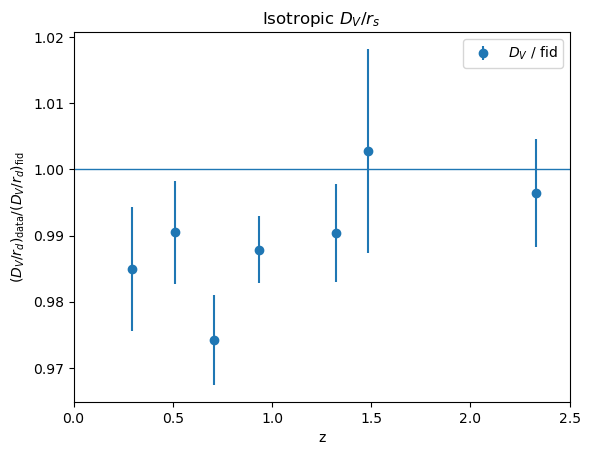

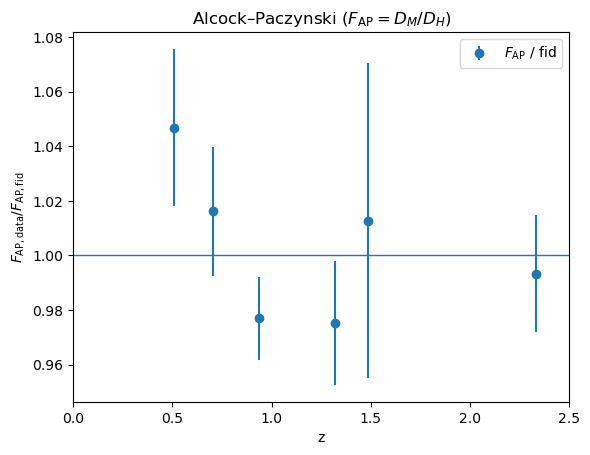

In [30]:
params_fid = np.zeros(Nparams)   # or whatever your fiducial is
plot_DV_and_FAP_relative_to_fid(data, cov, params_fid, mode="ratio")

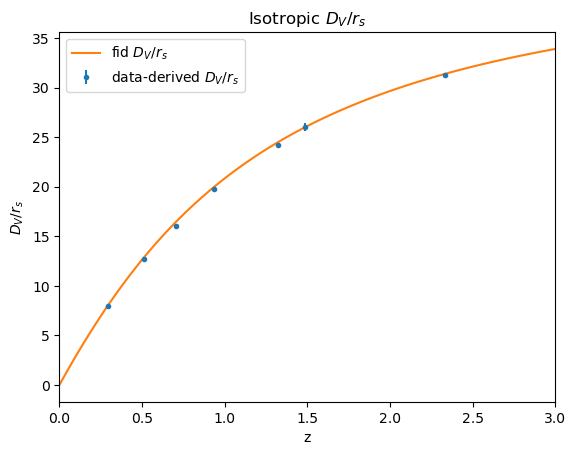

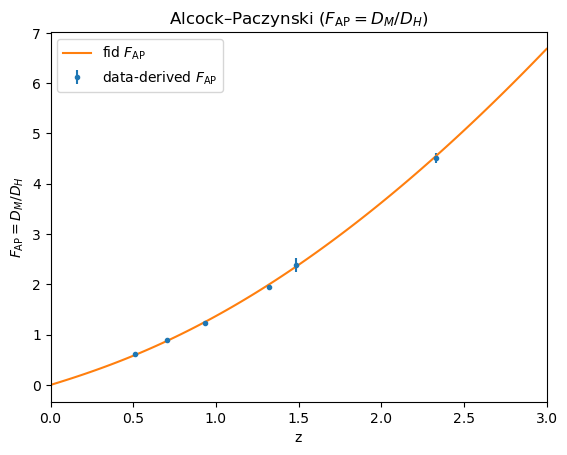

In [31]:
plot_DV_and_FAP_relative_to_fid(data, cov, params_fid, mode="value", xbounds=(0,3.0))

# Linear Regression

In [32]:
eps = 0.01
fid_params = np.zeros(Nparams)
dvec_0 = make_data_vector_from_rows(data, fid_params)

templates = []

for ii, p in enumerate(fid_params):
    
    dx = np.zeros_like(fid_params); dx[ii] += eps
    
    dvec_prime = make_data_vector_from_rows(data, fid_params + dx)
        
    templates += [ (dvec_prime - dvec_0) / eps, ]
    
templates = np.array(templates)

In [33]:
import numpy as np

# --- inputs you already have ---
# data: array of rows (z, value, label) in the same order as cov
# cov:  (Ndata, Ndata) covariance matrix
# dvec_0: fiducial theory vector (Ndata,)
# template: array from your loop, shape (Nparam, Ndata)

# 1) observed vector
d_obs = np.array([row[1] for row in data], dtype=float)

# 2) residual relative to fid
r = d_obs - dvec_0

# 3) design matrix (Ndata, Nparam)
T = np.asarray(templates, dtype=float).T

# 4) direct inverse of covariance
Cinv = np.linalg.inv(np.asarray(cov, dtype=float))

# 5a) Include Parameter Prior to Regularize
sigma_logH = 1.0
prior = np.diag( np.ones(Nparams) / sigma_logH**2 )

# 5b) Fisher / normal matrix and RHS
F = T.T @ Cinv @ T + prior                  # (Nparam, Nparam)
b = T.T @ Cinv @ r                    # (Nparam,)

# 6) best-fit parameter shift and its covariance
delta_theta = np.linalg.solve(F, b)   # preferred over inv(F) @ b
cov_theta = np.linalg.inv(F)

theta_hat = fid_params + delta_theta

print("theta_hat   =", theta_hat)
print("cov_theta =\n", cov_theta)
print("sigma =", np.sqrt(np.diag(cov_theta)))

# 7) (optional) chi2 at fid and at best-fit (linearized)
chi2_fid = float(r.T @ Cinv @ r)
r_best = r - T @ delta_theta
chi2_best = float(r_best.T @ Cinv @ r_best)

print("chi2_fid  =", chi2_fid)
print("chi2_best =", chi2_best)
print("Delta chi2 =", chi2_fid - chi2_best)

theta_hat   = [ 4.87501007e-02 -3.84740606e-02  1.10012297e-03  4.75004111e-03
  2.14390716e-03  1.67434599e-03  2.87041283e-07]
cov_theta =
 [[ 1.48951693e-03 -4.60157608e-04  1.94255850e-04 -2.30821275e-04
  -1.73251733e-04  1.12808667e-04  1.21204518e-08]
 [-4.60157607e-04  1.64859444e-04 -6.28361475e-05  5.17080256e-05
   4.26747341e-05 -3.13133925e-05 -3.29061588e-09]
 [ 1.94255849e-04 -6.28361475e-05  9.94227805e-05 -4.27713622e-05
  -4.23740783e-05  2.07589787e-05 -8.89434126e-10]
 [-2.30821277e-04  5.17080264e-05 -4.27713632e-05  2.92821026e-04
   1.66010884e-04 -1.15885797e-04  1.52206475e-08]
 [-1.73251734e-04  4.26747344e-05 -4.23740787e-05  1.66010883e-04
   1.28855891e-04  3.79536168e-06  1.44132890e-07]
 [ 1.12808668e-04 -3.13133930e-05  2.07589792e-05 -1.15885799e-04
   3.79536078e-06  2.05811136e-04 -1.93566540e-07]
 [ 1.21204450e-08 -3.29061410e-09 -8.89435955e-10  1.52206534e-08
   1.44132895e-07 -1.93566540e-07  1.00000000e+00]]
sigma = [0.03859426 0.01283976 0.00997

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_DV_and_FAP_ratio_with_bestfit(data_rows, cov, params_fid, params_best,
                                      *, prefer_file_DV=True, xbounds=(0,2.5)):
    """
    Plot data-derived ratios to fiducial for DV/rs and F_AP, with 1σ error bars,
    and overlay best-fit theory ratio curve: theory(best)/theory(fid).
    """

    # --- data-derived DV and F_AP with propagated errors ---
    z, dv, sdv, fap, sfap = derived_DV_and_FAP_from_data(
        data_rows, cov, prefer_file_DV=prefer_file_DV
    )

    # --- theory at those z's ---
    dv_fid   = np.array([theory_DV_over_rs(zz, params_fid)  for zz in z], float)
    dv_best  = np.array([theory_DV_over_rs(zz, params_best) for zz in z], float)
    fap_fid  = np.array([theory_FAP(zz, params_fid)         for zz in z], float)
    fap_best = np.array([theory_FAP(zz, params_best)        for zz in z], float)

    # ---------- DV ratio plot ----------
    fig = plt.figure()
    ax = plt.gca()

    m = np.isfinite(dv) & np.isfinite(sdv)
    ax.errorbar(
        z[m],
        dv[m] / dv_fid[m],
        yerr=sdv[m] / dv_fid[m],
        fmt="o",
        linestyle="none",
        label="data / fid"
    )

    # smooth-ish curve: just sort z and connect
    zs = np.arange(xbounds[0]+1e-5, xbounds[1], 0.01) #np.sort(z[m])
    dv_ratio_curve = np.array([theory_DV_over_rs(zz, params_best) / theory_DV_over_rs(zz, params_fid)
                               for zz in zs], float)
    ax.plot(zs, dv_ratio_curve, linestyle="-", label="best-fit / fid")

    ax.axhline(1.0, linewidth=1)
    ax.set_xlim(*xbounds)
    #ax.set_ylim(0.95, 1.025)

    ax.set_xlabel("z")
    ax.set_ylabel(r"$(D_V/r_s)_{\rm data}/(D_V/r_s)_{\rm fid}$")
    #ax.set_title(r"$D_V$ ratios")
    ax.legend()

    # ---------- F_AP ratio plot ----------
    fig = plt.figure()
    ax = plt.gca()

    m = np.isfinite(fap) & np.isfinite(sfap)
    ax.errorbar(
        z[m],
        fap[m] / fap_fid[m],
        yerr=sfap[m] / fap_fid[m],
        fmt="o",
        linestyle="none",
        label="data / fid"
    )

    fap_ratio_curve = np.array([theory_FAP(zz, params_best) / theory_FAP(zz, params_fid)
                                for zz in zs], float)
    ax.plot(zs, fap_ratio_curve, linestyle="-", label="best-fit / fid")

    ax.axhline(1.0, linewidth=1)
    ax.set_xlim(*xbounds)
    #ax.set_ylim(0.94, 1.1)
    ax.set_xlabel("z")
    ax.set_ylabel(r"$F_{\rm AP,data}/F_{\rm AP,fid}$")
    #ax.set_title(r"$F_{\rm AP}=D_M/D_H$ ratios")
    ax.legend()

    plt.show()

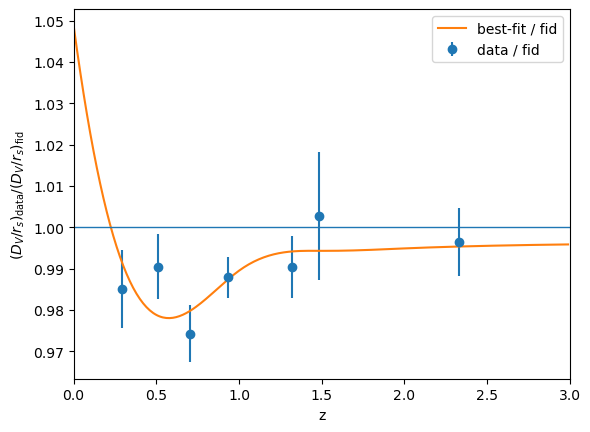

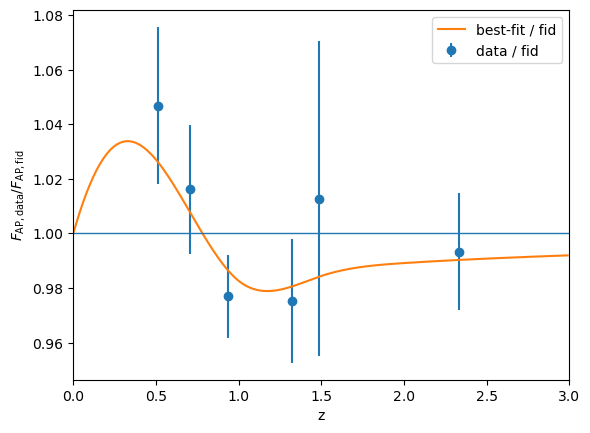

In [35]:
plot_DV_and_FAP_ratio_with_bestfit(
    data, cov,
    params_fid=fid_params,
    params_best=theta_hat,
    prefer_file_DV=True,
    xbounds=(0,3.0)
)

# Plot Confidence Interval of Predictions (Posterior-Predictive Distribution)

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_DV_and_FAP_ratio_with_ppd(
    data_rows,
    cov_data,
    params_fid,
    theta_hat,
    cov_theta,
    *,
    nsamp=5000,
    ci_list=(0.68, 0.95),
    z_grid=None,
    prefer_file_DV=True,
    random_seed=0,
):
    """
    Plot DV and F_AP ratios (data/fid) with:
      - data error bars (from cov_data)
      - best-fit theory curve (theta_hat/fid)
      - posterior predictive band from parameter uncertainty: theta ~ N(theta_hat, cov_theta)

    Notes:
      - This "PPD" band reflects uncertainty from parameters only.
      - If you want to include measurement noise too (true PPD for simulated data),
        you would additionally draw noise ~ N(0, cov_data) in the *observable space*.
    """
    rng = np.random.default_rng(random_seed)

    # --- data-derived points + errors ---
    z_pts, dv_data, sdv, fap_data, sfap = derived_DV_and_FAP_from_data(
        data_rows, cov_data, prefer_file_DV=prefer_file_DV
    )

    # z grid for smooth curves/bands
    if z_grid is None:
        # default: a dense grid spanning your point range
        zmin, zmax = np.min(z_pts), np.max(z_pts)
        z_grid = np.linspace(zmin, zmax, 300)
    else:
        zmin, zmax = z_grid[0], z_grid[-1]
        z_grid = np.asarray(z_grid, dtype=float)

    # --- fid curves on grid ---
    dv_fid_grid  = np.array([theory_DV_over_rs(z, params_fid) for z in z_grid], float)
    fap_fid_grid = np.array([theory_FAP(z, params_fid)        for z in z_grid], float)
    Hz_fid_grid = np.array([1/DH_per_rd(z, params_fid) for z in z_grid], float)
    wz_fid_grid = -1 + (1.0 + z_grid)/3.0 * np.gradient(np.log(Hz_fid_grid**2), z_grid)    
    
    # --- best-fit curves on grid ---
    dv_best_grid  = np.array([theory_DV_over_rs(z, theta_hat) for z in z_grid], float)
    fap_best_grid = np.array([theory_FAP(z, theta_hat)        for z in z_grid], float)
    Hz_best_grid = np.array([1/DH_per_rd(z, theta_hat) for z in z_grid], float)
    wz_best_grid = -1 + (1.0 + z_grid)/3.0 * np.gradient(np.log(Hz_best_grid**2), z_grid)    

    
    dv_ratio_best  = dv_best_grid / dv_fid_grid
    fap_ratio_best = fap_best_grid / fap_fid_grid
    

    # --- draw parameter samples and build ratio samples on grid ---
    theta_samps = rng.multivariate_normal(mean=theta_hat, cov=cov_theta, size=nsamp)

    dv_ratio_samps = np.empty((nsamp, z_grid.size), dtype=float)
    fap_ratio_samps = np.empty((nsamp, z_grid.size), dtype=float)
    Hzs_samps = np.empty((nsamp, z_grid.size), dtype=float)
    wzs_samps = np.empty((nsamp, z_grid.size), dtype=float)

    for i in range(nsamp):
        th = theta_samps[i]
        dv_th  = np.array([theory_DV_over_rs(z, th) for z in z_grid], float)
        fap_th = np.array([theory_FAP(z, th)        for z in z_grid], float)
        dv_ratio_samps[i, :]  = dv_th / dv_fid_grid
        fap_ratio_samps[i, :] = fap_th / fap_fid_grid
        Hzs_samps[i,:] = np.array( [1.0/DH_per_rd(z, th) for z in z_grid], float)
        wzs_samps[i,:] = -1 + (1.0 + z_grid)/3.0 * np.gradient(np.log(Hzs_samps[i,:]**2), z_grid)

    # helper to get bands
    def bands(arr, ci):
        lo = (1.0 - ci) / 2.0
        hi = 1.0 - lo
        qlo = np.quantile(arr, lo, axis=0)
        qhi = np.quantile(arr, hi, axis=0)
        qmed = np.quantile(arr, 0.5, axis=0)
        return qlo, qmed, qhi

    # --- DV ratio plot ---
    fig = plt.figure()
    ax = plt.gca()

    m = np.isfinite(dv_data) & np.isfinite(sdv)
    dv_fid_pts = np.array([theory_DV_over_rs(z, params_fid) for z in z_pts[m]], float)
    ax.errorbar(
        z_pts[m],
        dv_data[m] / dv_fid_pts,
        yerr=sdv[m] / dv_fid_pts,
        color='k',
        fmt="o",
        linestyle="none",
        label="data / fid",
    )

    # PPD bands (plot widest first)
    alpha = 0.2
    for ci in sorted(ci_list, reverse=True):
        lo, med, hi = bands(dv_ratio_samps, ci)
        ax.fill_between(z_grid, lo, hi, color='C0', alpha=alpha, label=f"{int(ci*100)}% PPD")
        alpha += 0.3

    ax.plot(z_grid, dv_ratio_best,'C0', linestyle="-", label="best-fit / fid")
    ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
    ax.set_xlim(zmin, zmax)
    ax.set_ylim(0.95, 1.05)
    ax.set_xlabel("z")
    ax.set_ylabel(r"$(D_V/r_s)_{\rm data}/(D_V/r_s)_{\rm fid}$")
    #ax.set_title(r"$D_V$ ratios with PPD band")
    ax.legend()

    # --- F_AP ratio plot ---
    fig = plt.figure()
    ax = plt.gca()

    m = np.isfinite(fap_data) & np.isfinite(sfap)
    fap_fid_pts = np.array([theory_FAP(z, params_fid) for z in z_pts[m]], float)
    ax.errorbar(
        z_pts[m],
        fap_data[m] / fap_fid_pts,
        yerr=sfap[m] / fap_fid_pts,
        color='k',
        fmt="o",
        linestyle="none",
        label="data / fid",
    )

    alpha = 0.2
    for ci in sorted(ci_list, reverse=True):
        lo, med, hi = bands(fap_ratio_samps, ci)
        ax.fill_between(z_grid, lo, hi, alpha=alpha, color='C0', label=f"{int(ci*100)}% PPD")
        alpha += 0.3

    ax.plot(z_grid, fap_ratio_best, 'C0', linestyle="-", label="best-fit / fid")
    ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
    ax.set_xlim(zmin, zmax)
    ax.set_ylim(0.9, 1.1)

    ax.set_xlabel("z")
    ax.set_ylabel(r"$F_{\rm AP,data}/F_{\rm AP,fid}$")
    #ax.set_title(r"$F_{\rm AP}=D_M/D_H$ ratios with PPD band")
    ax.legend()
    
    ## w(z) plot
    fig = plt.figure()
    ax = plt.gca()

    m = np.isfinite(dv_data) & np.isfinite(sdv)


    # PPD bands (plot widest first)
    alpha = 0.2
    for ci in sorted(ci_list, reverse=True):
        lo, med, hi = bands(wzs_samps, ci)
        ax.fill_between(z_grid, lo, hi, color='C0', alpha=alpha, label=f"{int(ci*100)}% PPD")
        alpha += 0.3

    ax.plot(z_grid, wz_best_grid,'C0', linestyle="-")
    ax.plot(z_grid, wz_fid_grid,'k', linestyle="-", label='Fiducial LCDM')

    #ax.plot(z_grid, wz_fid_grid - 0.1*(1 + z_grid)**3/(1 + Om_fid*z_grid*(3 + z_grid*(3 + z_grid)))**2, 'C2')
    
    ax.set_xlim(zmin, zmax)
    ax.set_ylim(-1.2, 0.5)
    ax.set_xlabel("z")
    ax.set_ylabel(r"$w(z)$")
    #ax.set_title(r"$D_V$ ratios with PPD band")
    
    ax.axhline(-1.0, color='k', linestyle='--', linewidth=1, label=r'$\Lambda$')
    ax.axhline(.0, color='k', linestyle=':', linewidth=1, label=r'Matter')

    ax.legend(ncol=4)
    plt.show()

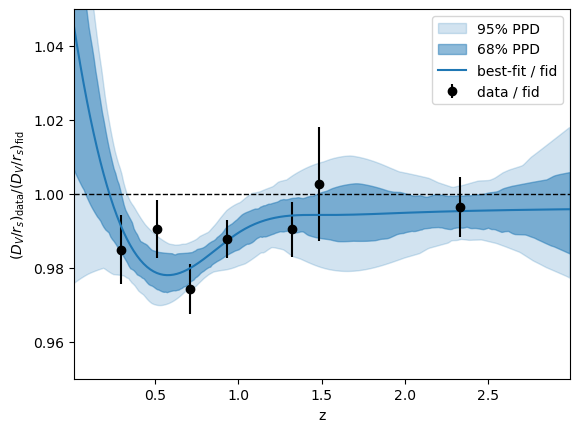

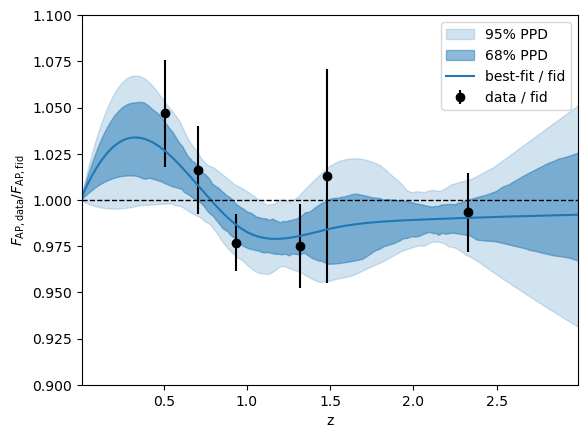

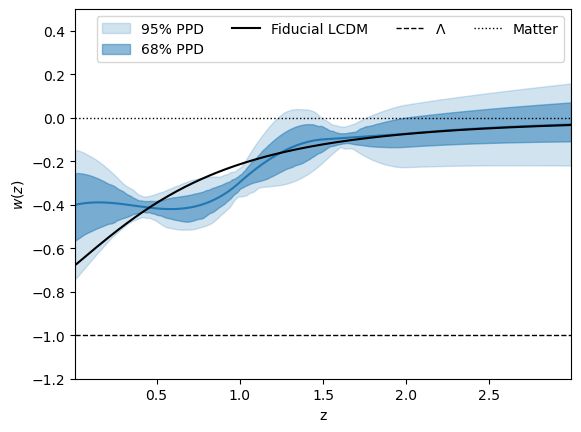

In [45]:
plot_DV_and_FAP_ratio_with_ppd(
    data_rows=data,
    cov_data=cov,
    params_fid=fid_params,
    theta_hat=theta_hat,
    cov_theta=cov_theta,
    nsamp=100,
    z_grid = np.arange(0.01, 3.0, 0.01)
)

# How much information is in $D_V$ vs $F_{AP}$?

## Your task: construct a data vector with only $D_V$ and see how fit results compare.

What if a prior is set on how fast dark energy can evolve?

# How does the non-parametric solution compare changing cosmology parameters?

## Your task: Compute the change in $D_H/r_d$ from a known cosmological parameter, like $\omega_m$. Is it consistent with the non-parametric solution?
Or, fix $\omega_m$ etc. to Planck LCDM. How does dark energy have to evolve?

# Compute the linear growth rate given the non-parametric H(z), assuming we know $r_d$. How does it compare to the fiducial growth function?